In [1]:
!pip install pandas numpy scikit-learn imbalanced-learn matplotlib seaborn --quiet

In [2]:
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import os

from collections import Counter
from sqlalchemy import create_engine
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

warnings.filterwarnings('ignore')
np.random.seed(42)

print("Semua library berhasil diimport.")

Semua library berhasil diimport.


In [3]:
# koneksi ke database mysql
DB_HOST     = os.getenv('DB_HOST', 'localhost')
DB_PORT     = int(os.getenv('DB_PORT', '3306'))
DB_USER     = os.getenv('DB_USER', 'root')
DB_PASSWORD = os.getenv('DB_PASSWORD', '')
DB_NAME     = os.getenv('DB_NAME', 'datawarehouse_om')

# engine koneksi (SQLAlchemy)
engine = create_engine(
    f"mysql+pymysql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
)
print(f"Koneksi ke database siap: {DB_HOST}:{DB_PORT}/{DB_NAME}")

Koneksi ke database siap: localhost:3306/datawarehouse_om


In [4]:
query = """
    SELECT
        f.fact_id,
        f.severity,
        t.month,
        m.scope_of_work,
        s.city
    FROM fact_maintenance_activity f
    JOIN dim_time             t  ON f.time_id        = t.time_id
    JOIN dim_maintenance_type m  ON f.maintenance_id = m.maintenance_id
    JOIN dim_site             s  ON f.site_id        = s.site_id
        AND s.is_current = 1
"""
df = pd.read_sql(query, con=engine)
print(f"Data berhasil diambil: {df.shape[0]:,} baris × {df.shape[1]} kolom")
print(df.head(3))

Data berhasil diambil: 52,427 baris × 5 kolom
   fact_id severity  month scope_of_work                 city
0     1421    minor      1            q2  kabupaten bondowoso
1     5963    minor      2            b4  kabupaten bondowoso
2     9883    minor      3           vw2  kabupaten bondowoso


In [5]:
# DATA PREPARATION
NUM_COLS = ['month']

for col in NUM_COLS:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print("Tipe data setelah konversi:")
print(df.dtypes)
print(f"\nNilai null per kolom:")
print(df.isnull().sum())

Tipe data setelah konversi:
fact_id           int64
severity         object
month             int64
scope_of_work    object
city             object
dtype: object

Nilai null per kolom:
fact_id          0
severity         0
month            0
scope_of_work    0
city             0
dtype: int64


In [6]:
# distribusi kelas target
sev_counts = df['severity'].value_counts()
total      = len(df)

print("DISTRIBUSI TARGET (SEVERITY)")
for label, count in sev_counts.items():
    pct = count / total * 100
    bar = "█" * int(pct / 2)
    print(f"  {label:<8}: {count:>6} ({pct:5.1f}%)  {bar}")

ratio = sev_counts['minor'] / sev_counts['major']
print(f"\nImbalance Ratio (minor:major) = {ratio:.2f}:1")
print(f"Data tidak seimbang")

DISTRIBUSI TARGET (SEVERITY)
  minor   :  42796 ( 81.6%)  ████████████████████████████████████████
  major   :   9631 ( 18.4%)  █████████

Imbalance Ratio (minor:major) = 4.44:1
Data tidak seimbang


In [7]:
# definisi fitur
FEATURE_COLS = [
    # waktu
    'month',
    # kategorik
    'scope_of_work', 'city'
]
TARGET_COL = 'severity'

# encoding kategorik
CAT_COLS = ['scope_of_work', 'city']
label_encoders = {}

for col in CAT_COLS:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str).str.strip().str.lower())
    label_encoders[col] = le
    print(f"  Encoded '{col}' → {len(le.classes_)} kelas unik")

  Encoded 'scope_of_work' → 52 kelas unik
  Encoded 'city' → 31 kelas unik


In [8]:
# Encode target: minor = 0, major = 1
df['severity_encoded'] = df[TARGET_COL].str.strip().str.lower().map({'minor': 0, 'major': 1})

X = df[FEATURE_COLS].copy()
y = df['severity_encoded'].copy()

print(f"Fitur  (X) : {X.shape}")
print(f"Target (y) : {y.shape} →  0 = minor, 1 = major")

Fitur  (X) : (52427, 3)
Target (y) : (52427,) →  0 = minor, 1 = major


In [9]:
# split data 80:20
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size   = 0.2,
    random_state= 42,
    stratify    = y      # proporsi kelas
)

print("HASIL SPLIT DATA")
print(f"  Training (80%): {len(X_train):>6} baris")
print(f"  Testing  (20%): {len(X_test):>6} baris")
print(f"Total data      : {len(X):>6} baris")
print()
print("Distribusi Training (sebelum SMOTE):")
for label, count in sorted(Counter(y_train).items()):
    name = 'major' if label == 1 else 'minor'
    print(f"    {name}: {count}")

HASIL SPLIT DATA
  Training (80%):  41941 baris
  Testing  (20%):  10486 baris
Total data      :  52427 baris

Distribusi Training (sebelum SMOTE):
    minor: 34236
    major: 7705


In [10]:
# SMOTEEE
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("DISTRIBUSI SETELAH SMOTE (Data Training)")

before = Counter(y_train)
after  = Counter(y_train_res)

print(f"  {'Kelas':<10} {'Sebelum':>10} {'Sesudah':>10}  {'Δ Penambahan':>14}")
print(f"  {'-'*48}")
for label in sorted(after.keys()):
    name = 'major' if label == 1 else 'minor'
    diff = after[label] - before[label]
    print(f"  {name:<10} {before[label]:>10} {after[label]:>10}  +{diff:>13}")

ratio_after = after[0] / after[1]
print(f"\n  Imbalance ratio setelah SMOTE: {ratio_after:.2f}:1")
print(f"  Total training setelah SMOTE : {len(X_train_res)} baris")
print()
print("SMOTE berhasil menyeimbangkan data training") # tidak pakai data testing (menghindari data leakage)

DISTRIBUSI SETELAH SMOTE (Data Training)
  Kelas         Sebelum    Sesudah    Δ Penambahan
  ------------------------------------------------
  minor           34236      34236  +            0
  major            7705      34236  +        26531

  Imbalance ratio setelah SMOTE: 1.00:1
  Total training setelah SMOTE : 68472 baris

SMOTE berhasil menyeimbangkan data training


In [11]:
# CROSS VALIDATION (K-FOLD)
cv_pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42, k_neighbors=5)),
    ('rf',    RandomForestClassifier(
                  n_estimators=100,
                  random_state=42,
                  n_jobs=-1
              ))
])

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = cross_validate(
    cv_pipeline, X, y,
    cv      = skf,
    scoring = ['accuracy', 'precision_weighted', 'recall_weighted', 'f1_weighted'],
    n_jobs  = -1,
    return_train_score=True
)

print("HASIL CROSS-VALIDATION (5-Fold, Weighted Avg)")
metrics_cv = {
    'Accuracy' : cv_results['test_accuracy'],
    'Precision': cv_results['test_precision_weighted'],
    'Recall'   : cv_results['test_recall_weighted'],
    'F1-Score' : cv_results['test_f1_weighted'],
}
print(f"  {'Metrik':<12} {'Fold 1':>8} {'Fold 2':>8} {'Fold 3':>8} {'Fold 4':>8} {'Fold 5':>8}   {'Mean':>8}")
print(f"  {'-'*70}")
for metric, vals in metrics_cv.items():
    fold_str = '  '.join([f"{v:.4f}" for v in vals])
    print(f"  {metric:<12} {fold_str}   {vals.mean():.4f}  ±{vals.std():.4f}")

print()
print(f"CV selesai, Akurasi rata-rata: {cv_results['test_accuracy'].mean()*100:.2f}% ± {cv_results['test_accuracy'].std()*100:.2f}%")

HASIL CROSS-VALIDATION (5-Fold, Weighted Avg)
  Metrik         Fold 1   Fold 2   Fold 3   Fold 4   Fold 5       Mean
  ----------------------------------------------------------------------
  Accuracy     0.6855  0.6824  0.6946  0.6815  0.6851   0.6858  ±0.0046
  Precision    0.8308  0.8288  0.8316  0.8272  0.8347   0.8306  ±0.0025
  Recall       0.6855  0.6824  0.6946  0.6815  0.6851   0.6858  ±0.0046
  F1-Score     0.7206  0.7179  0.7285  0.7171  0.7204   0.7209  ±0.0040

CV selesai, Akurasi rata-rata: 68.58% ± 0.46%


In [12]:
# random forest classifier
rf_final = RandomForestClassifier(
    n_estimators = 100,
    random_state = 42,
    n_jobs       = -1
)

# training dengan SMOTE
rf_final.fit(X_train_res, y_train_res)
print("Model Random Forest berhasil dilatih pada data training + SMOTE.")

# testing tanpa SMOTE
y_pred = rf_final.predict(X_test)
y_pred_proba = rf_final.predict_proba(X_test)

print(f"Prediksi selesai untuk {len(y_test)} data testing.")

Model Random Forest berhasil dilatih pada data training + SMOTE.
Prediksi selesai untuk 10486 data testing.


In [13]:
# EVALUASI MODEL
acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='weighted')
rec  = recall_score(y_test, y_pred, average='weighted')
f1   = f1_score(y_test, y_pred, average='weighted')

prec_major = precision_score(y_test, y_pred, pos_label=1)
rec_major  = recall_score(y_test, y_pred, pos_label=1)
f1_major   = f1_score(y_test, y_pred, pos_label=1)

prec_minor = precision_score(y_test, y_pred, pos_label=0)
rec_minor  = recall_score(y_test, y_pred, pos_label=0)
f1_minor   = f1_score(y_test, y_pred, pos_label=0)

print("HASIL EVALUASI MODEL RANDOM FOREST + SMOTE")
print(f"  Accuracy  (Weighted) : {acc:.4f}  ({acc*100:.2f}%)")
print(f"  Precision (Weighted) : {prec:.4f}  ({prec*100:.2f}%)")
print(f"  Recall    (Weighted) : {rec:.4f}  ({rec*100:.2f}%)")
print(f"  F1-Score  (Weighted) : {f1:.4f}  ({f1*100:.2f}%)")
print()

print("Classification Report Lengkap:")
print(classification_report(y_test, y_pred, target_names=['minor', 'major']))

HASIL EVALUASI MODEL RANDOM FOREST + SMOTE
  Accuracy  (Weighted) : 0.6842  (68.42%)
  Precision (Weighted) : 0.8334  (83.34%)
  Recall    (Weighted) : 0.6842  (68.42%)
  F1-Score  (Weighted) : 0.7196  (71.96%)

Classification Report Lengkap:
              precision    recall  f1-score   support

       minor       0.94      0.65      0.77      8560
       major       0.35      0.82      0.49      1926

    accuracy                           0.68     10486
   macro avg       0.65      0.74      0.63     10486
weighted avg       0.83      0.68      0.72     10486



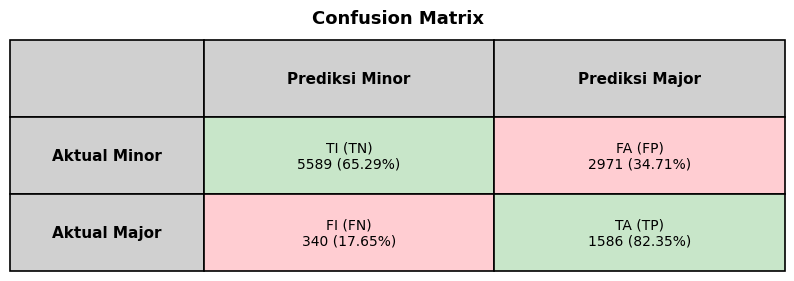

In [14]:
# confusion matrix (visualisasi)
cm = confusion_matrix(y_test, y_pred)

# Ekstrak nilai confusion matrix
TN = cm[0][0]  # Prediksi Minor, Aktual Minor (Benar)
FP = cm[0][1]  # Prediksi Major, Aktual Minor (Salah)
FN = cm[1][0]  # Prediksi Minor, Aktual Major (Salah)
TP = cm[1][1]  # Prediksi Major, Aktual Major (Benar)

total_minor_actual = TN + FP
total_major_actual = FN + TP

fig, ax = plt.subplots(figsize=(10, 3))
ax.axis('off')

table_data = [
    ['',              'Prediksi Minor',               'Prediksi Major'             ],
    ['Aktual Minor',  f'TI (TN)\n{TN} ({TN/total_minor_actual*100:.2f}%)', f'FA (FP)\n{FP} ({FP/total_minor_actual*100:.2f}%)'],
    ['Aktual Major',  f'FI (FN)\n{FN} ({FN/total_major_actual*100:.2f}%)', f'TA (TP)\n{TP} ({TP/total_major_actual*100:.2f}%)'],
]

table = ax.table(
    cellText=table_data,
    loc='center',
    cellLoc='center',
    bbox=[0, 0, 1, 1] 
)

table.auto_set_font_size(False)
table.set_fontsize(11)

col_widths = [0.25, 0.375, 0.375]
for (row, col), cell in table.get_celld().items():
    cell.set_width(col_widths[col])
    cell.set_height(0.33)
    cell.set_edgecolor('black')
    cell.set_linewidth(1.2)

    if row == 0 or col == 0:
        cell.set_facecolor('#D0D0D0')
        cell.set_text_props(fontweight='bold', fontsize=11)
    elif row == 1 and col == 1:
        cell.set_facecolor('#C8E6C9')
        cell.set_text_props(fontsize=10)
    elif row == 2 and col == 2:
        cell.set_facecolor('#C8E6C9')
        cell.set_text_props(fontsize=10)
    else:
        cell.set_facecolor('#FFCDD2')
        cell.set_text_props(fontsize=10)

ax.set_title('Confusion Matrix',
             fontsize=13, fontweight='bold', pad=12)
plt.show()

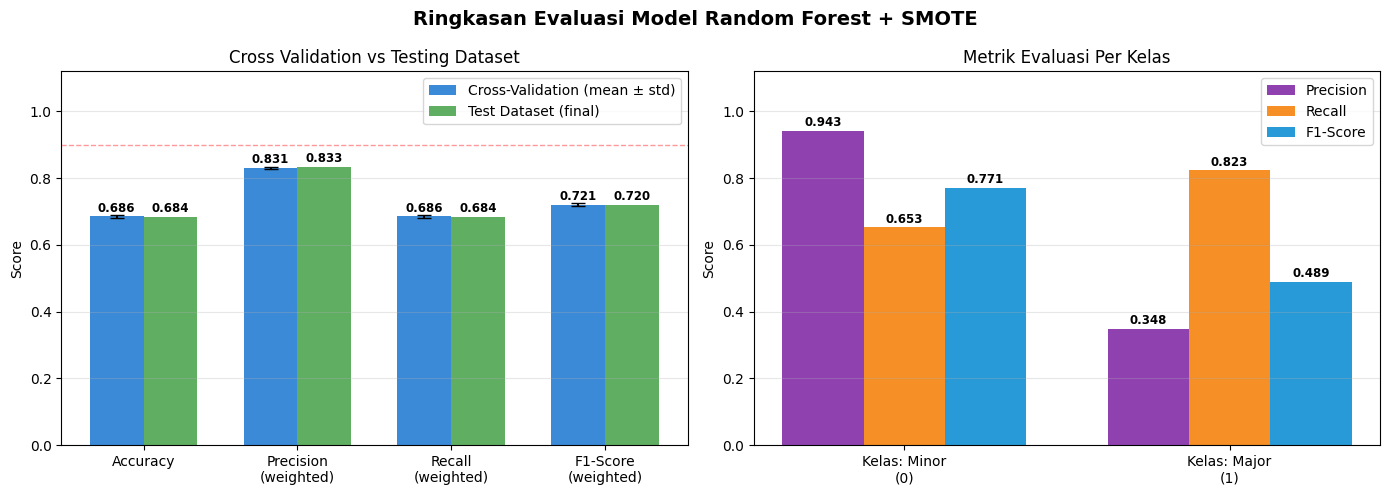

In [15]:
# EVALUASI PAKAI CV + TESTING
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Ringkasan Evaluasi Model Random Forest + SMOTE', fontsize=14, fontweight='bold')

# panel kiri
ax1 = axes[0]
metrics_names  = ['Accuracy', 'Precision\n(weighted)', 'Recall\n(weighted)', 'F1-Score\n(weighted)']
cv_means  = [
    cv_results['test_accuracy'].mean(),
    cv_results['test_precision_weighted'].mean(),
    cv_results['test_recall_weighted'].mean(),
    cv_results['test_f1_weighted'].mean(),
]
cv_stds   = [
    cv_results['test_accuracy'].std(),
    cv_results['test_precision_weighted'].std(),
    cv_results['test_recall_weighted'].std(),
    cv_results['test_f1_weighted'].std(),
]
test_vals  = [acc, prec, rec, f1]

x      = np.arange(len(metrics_names))
width  = 0.35
colors_bar = ['#1976D2', '#43A047']

bars1 = ax1.bar(x - width/2, cv_means, width, yerr=cv_stds, capsize=5,
                label='Cross-Validation (mean ± std)', color=colors_bar[0], alpha=0.85)
bars2 = ax1.bar(x + width/2, test_vals, width,
                label='Test Dataset (final)', color=colors_bar[1], alpha=0.85)

for bar, val in zip(bars1, cv_means):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{val:.3f}', ha='center', va='bottom', fontsize=8.5, fontweight='bold')
for bar, val in zip(bars2, test_vals):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{val:.3f}', ha='center', va='bottom', fontsize=8.5, fontweight='bold')

ax1.set_ylim(0, 1.12)
ax1.set_xticks(x)
ax1.set_xticklabels(metrics_names)
ax1.set_ylabel('Score')
ax1.set_title('Cross Validation vs Testing Dataset')
ax1.legend()
ax1.axhline(y=0.9, color='red', linestyle='--', alpha=0.4, linewidth=1, label='Target ≥ 0.90')
ax1.grid(axis='y', alpha=0.3)

# panel kanan
ax2 = axes[1]
kelas      = ['minor', 'major']
prec_vals  = [prec_minor, prec_major]
rec_vals   = [rec_minor,  rec_major]
f1_vals    = [f1_minor,   f1_major]

x2    = np.arange(len(kelas))
w2    = 0.25
ax2.bar(x2 - w2, prec_vals, w2, label='Precision', color='#7B1FA2', alpha=0.85)
ax2.bar(x2,      rec_vals,  w2, label='Recall',    color='#F57C00', alpha=0.85)
ax2.bar(x2 + w2, f1_vals,   w2, label='F1-Score',  color='#0288D1', alpha=0.85)

for vals, offset in [(prec_vals, -w2), (rec_vals, 0), (f1_vals, w2)]:
    for i, v in enumerate(vals):
        ax2.text(i + offset, v + 0.005, f'{v:.3f}',
                 ha='center', va='bottom', fontsize=8.5, fontweight='bold')

ax2.set_ylim(0, 1.12)
ax2.set_xticks(x2)
ax2.set_xticklabels(['Kelas: Minor\n(0)', 'Kelas: Major\n(1)'])
ax2.set_ylabel('Score')
ax2.set_title('Metrik Evaluasi Per Kelas')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [16]:
# feature importance
fi_df = pd.DataFrame({
    'Feature'   : FEATURE_COLS,
    'Importance': rf_final.feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)

print("FEATURE IMPORTANCE")
print(f"{'-'*55}")
for i, row in fi_df.iterrows():
    bar = "█" * int(row['Importance'] * 60)
    print(f"{i+1:2}. {row['Feature']:<20} {row['Importance']:.4f}  {bar}")

FEATURE IMPORTANCE
-------------------------------------------------------
 1. scope_of_work        0.4251  █████████████████████████
 2. city                 0.3976  ███████████████████████
 3. month                0.1773  ██████████


In [17]:
# insights
top3_features = fi_df.head(3)['Feature'].tolist()
top1 = fi_df.iloc[0]

print("KEY INSIGHTS - MODEL RANDOM FOREST + SMOTE")
print(f"{'-'*55}")
print(f"1) Fitur paling berpengaruh: '{top1['Feature']}'")
print(f"   (Importance: {top1['Importance']:.4f})")
print()
print(f"2) Akurasi model: {acc*100:.2f}%")
print(f"   (Cross-validation: {cv_results['test_accuracy'].mean()*100:.2f}% ± {cv_results['test_accuracy'].std()*100:.2f}%)")
print()
print(f"3) SMOTE berhasil mengatasi imbalance {sev_counts['minor']/sev_counts['major']:.1f}:1")
print(f"   Precision major: {prec_major*100:.2f}% | Recall major: {rec_major*100:.2f}%")
print()
print(f"4) Model stabil dengan std rendah di semua fold CV")
print()
if acc >= 0.90:
    print(f"Status: SANGAT BAIK - Accuracy ≥ 90%")
elif acc >= 0.80:
    print(f"Status: BAIK - Accuracy ≥ 80%")
else:
    print(f"Status: Perlu ditingkatkan - Accuracy < 80%")
print(f"{'-'*55}")

KEY INSIGHTS - MODEL RANDOM FOREST + SMOTE
-------------------------------------------------------
1) Fitur paling berpengaruh: 'scope_of_work'
   (Importance: 0.4251)

2) Akurasi model: 68.42%
   (Cross-validation: 68.58% ± 0.46%)

3) SMOTE berhasil mengatasi imbalance 4.4:1
   Precision major: 34.80% | Recall major: 82.35%

4) Model stabil dengan std rendah di semua fold CV

Status: Perlu ditingkatkan - Accuracy < 80%
-------------------------------------------------------


In [18]:
# # EKSPERIMEN 1: HYPERPARAMETER TUNING (Random Forest)
# from sklearn.model_selection import GridSearchCV

# print("=" * 60)
# print("EKSPERIMEN 1: HYPERPARAMETER TUNING - RANDOM FOREST")
# print("=" * 60)

# # Parameter grid untuk tuning
# param_grid = {
#     'n_estimators'     : [50, 100, 200],
#     'max_depth'        : [5, 10, 15, 20, None],
#     'min_samples_split': [2, 5, 10],
#     'min_samples_leaf' : [1, 2, 4],
#     'max_features'     : ['sqrt', 'log2']
# }

# rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)

# # GridSearchCV dengan stratified fold
# grid_search = GridSearchCV(
#     rf_base, 
#     param_grid,
#     cv=5,
#     scoring='f1_weighted',  # F1 lebih cocok untuk imbalanced
#     n_jobs=-1,
#     verbose=1
# )

# print("\nMencari parameter terbaik... (ini butuh waktu)")
# grid_search.fit(X_train_res, y_train_res)

# print(f"\nParameter terbaik: {grid_search.best_params_}")
# print(f"Best CV Score (F1): {grid_search.best_score_:.4f}")

# # Evaluasi dengan best model
# best_rf = grid_search.best_estimator_
# y_pred_best = best_rf.predict(X_test)

# acc_best  = accuracy_score(y_test, y_pred_best)
# prec_best = precision_score(y_test, y_pred_best, average='weighted')
# rec_best  = recall_score(y_test, y_pred_best, average='weighted')
# f1_best   = f1_score(y_test, y_pred_best, average='weighted')

# print(f"\n--- HASIL TEST DATASET (Best RF) ---")
# print(f"Accuracy  : {acc_best:.4f}  ({acc_best*100:.2f}%)")
# print(f"Precision : {prec_best:.4f}  ({prec_best*100:.2f}%)")
# print(f"Recall    : {rec_best:.4f}  ({rec_best*100:.2f}%)")
# print(f"F1-Score  : {f1_best:.4f}  ({f1_best*100:.2f}%)")

# improvement = (acc_best - acc) * 100
# print(f"\n✓ Improvement dari model sebelumnya: +{improvement:.2f}%")
# if acc_best >= 0.80:
#     print("✓✓ TARGET TERCAPAI: Accuracy ≥ 80% ✓✓")

In [19]:
# # Install XGBoost
# import subprocess
# import sys
# print("Installing XGBoost...")
# subprocess.check_call([sys.executable, "-m", "pip", "install", "xgboost", "-q"])
# print("XGBoost installed!")

In [20]:
# # EKSPERIMEN 2: XGBoost (Gradient Boosting - lebih powerful)
# from xgboost import XGBClassifier

# print("\n" + "=" * 60)
# print("EKSPERIMEN 2: XGBoost (Gradient Boosting)")
# print("=" * 60)

# # Hitung scale_pos_weight untuk handle imbalance
# scale_pos = len(y_train_res[y_train_res == 0]) / len(y_train_res[y_train_res == 1])

# xgb_model = XGBClassifier(
#     n_estimators=100,
#     max_depth=7,
#     learning_rate=0.1,
#     scale_pos_weight=scale_pos,  # Handle imbalance
#     random_state=42,
#     n_jobs=-1,
#     eval_metric='logloss',
#     early_stopping_rounds=10
# )

# # Training
# xgb_model.fit(
#     X_train_res, y_train_res,
#     eval_set=[(X_test, y_test)],
#     verbose=False
# )

# y_pred_xgb = xgb_model.predict(X_test)

# acc_xgb  = accuracy_score(y_test, y_pred_xgb)
# prec_xgb = precision_score(y_test, y_pred_xgb, average='weighted')
# rec_xgb  = recall_score(y_test, y_pred_xgb, average='weighted')
# f1_xgb   = f1_score(y_test, y_pred_xgb, average='weighted')

# print(f"\n--- HASIL TEST DATASET (XGBoost) ---")
# print(f"Accuracy  : {acc_xgb:.4f}  ({acc_xgb*100:.2f}%)")
# print(f"Precision : {prec_xgb:.4f}  ({prec_xgb*100:.2f}%)")
# print(f"Recall    : {rec_xgb:.4f}  ({rec_xgb*100:.2f}%)")
# print(f"F1-Score  : {f1_xgb:.4f}  ({f1_xgb*100:.2f}%)")

# improvement_xgb = (acc_xgb - acc) * 100
# print(f"\n✓ Improvement dari model awal: +{improvement_xgb:.2f}%")
# if acc_xgb >= 0.80:
#     print("✓✓ TARGET TERCAPAI: Accuracy ≥ 80% ✓✓")

In [21]:
# # EKSPERIMEN 3: Random Forest dengan class_weight='balanced' (alternatif SMOTE)
# print("\n" + "=" * 60)
# print("EKSPERIMEN 3: Random Forest dengan class_weight='balanced'")
# print("=" * 60)

# rf_balanced = RandomForestClassifier(
#     n_estimators=200,
#     max_depth=15,
#     min_samples_split=5,
#     min_samples_leaf=2,
#     class_weight='balanced',  # Otomatis handle imbalance
#     random_state=42,
#     n_jobs=-1
# )

# # Training langsung pada X_train tanpa SMOTE
# rf_balanced.fit(X_train, y_train)
# y_pred_balanced = rf_balanced.predict(X_test)

# acc_balanced  = accuracy_score(y_test, y_pred_balanced)
# prec_balanced = precision_score(y_test, y_pred_balanced, average='weighted')
# rec_balanced  = recall_score(y_test, y_pred_balanced, average='weighted')
# f1_balanced   = f1_score(y_test, y_pred_balanced, average='weighted')

# print(f"\n--- HASIL TEST DATASET (RF + class_weight='balanced') ---")
# print(f"Accuracy  : {acc_balanced:.4f}  ({acc_balanced*100:.2f}%)")
# print(f"Precision : {prec_balanced:.4f}  ({prec_balanced*100:.2f}%)")
# print(f"Recall    : {rec_balanced:.4f}  ({rec_balanced*100:.2f}%)")
# print(f"F1-Score  : {f1_balanced:.4f}  ({f1_balanced*100:.2f}%)")

# improvement_balanced = (acc_balanced - acc) * 100
# print(f"\n✓ Improvement dari model awal: +{improvement_balanced:.2f}%")
# if acc_balanced >= 0.80:
#     print("✓✓ TARGET TERCAPAI: Accuracy ≥ 80% ✓✓")

In [22]:
# # PERBANDINGAN SEMUA MODEL
# print("\n" + "=" * 80)
# print("RINGKASAN PERBANDINGAN SEMUA MODEL")
# print("=" * 80)

# comparison_df = pd.DataFrame({
#     'Model': [
#         'Original RF + SMOTE',
#         'RF (Tuned) + SMOTE',
#         'XGBoost + SMOTE',
#         'RF + class_weight'
#     ],
#     'Accuracy': [acc, acc_best, acc_xgb, acc_balanced],
#     'Precision': [prec, prec_best, prec_xgb, prec_balanced],
#     'Recall': [rec, rec_best, rec_xgb, rec_balanced],
#     'F1-Score': [f1, f1_best, f1_xgb, f1_balanced],
# })

# comparison_df = comparison_df.sort_values('Accuracy', ascending=False).reset_index(drop=True)
# comparison_df['Rank'] = range(1, len(comparison_df) + 1)

# print(comparison_df.to_string(index=False))

# best_model_name = comparison_df.iloc[0]['Model']
# best_accuracy   = comparison_df.iloc[0]['Accuracy']

# print(f"\n{'─' * 80}")
# print(f"🏆 MODEL TERBAIK: {best_model_name}")
# print(f"   Accuracy: {best_accuracy*100:.2f}%")
# if best_accuracy >= 0.80:
#     print(f"   ✓✓ TARGET TERCAPAI: Accuracy ≥ 80% ✓✓")
# else:
#     print(f"   ⚠ Masih dibawah target 80%, coba strategi lain")
# print(f"{'─' * 80}")

# # Visualisasi perbandingan
# fig, ax = plt.subplots(figsize=(12, 5))
# x_pos = np.arange(len(comparison_df))
# bars = ax.bar(x_pos, comparison_df['Accuracy'] * 100, color=['#4CAF50', '#FF9800', '#2196F3', '#9C27B0'], alpha=0.8, edgecolor='black', linewidth=1.5)

# ax.axhline(y=80, color='red', linestyle='--', linewidth=2, label='Target: 80%', alpha=0.7)
# ax.set_ylim(0, 100)
# ax.set_ylabel('Accuracy (%)', fontsize=11, fontweight='bold')
# ax.set_title('Perbandingan Accuracy Semua Model', fontsize=13, fontweight='bold')
# ax.set_xticks(x_pos)
# ax.set_xticklabels(comparison_df['Model'], rotation=15, ha='right')
# ax.legend()
# ax.grid(axis='y', alpha=0.3)

# # Tambah nilai di atas bar
# for bar, val in zip(bars, comparison_df['Accuracy'] * 100):
#     height = bar.get_height()
#     ax.text(bar.get_x() + bar.get_width()/2., height,
#             f'{val:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=10)

# plt.tight_layout()
# plt.show()